# Section 4 — Le Modèle : Attention Model (AM)

**Fichier source** : `model.py`

---

## Architecture générale

Notre modèle est un **Attention Model** inspiré de Kool et al. (2019 — *Attention, Learn to Solve Routing Problems!*). Il est composé de deux parties :

```
                    ┌─────────────────────────────────┐
node_features       │  ENCODEUR (Transformer)          │
(N, 7)    ──────►  │  Linear → 3× Self-Attention      │  ──► h : embeddings (N, 128)
                    │  Capte les relations entre nœuds │
                    └─────────────────────────────────┘
                                   │  (calculé une seule fois par instance)
                                   ▼
action_features     ┌─────────────────────────────────┐
(N, 5)    ──────►  │  DÉCODEUR contextuel             │
current_node ───►  │  Contexte = [h_cur | h_moy | g]  │  ──► logits (N,)
dynamic_global ──► │  Score = q·k / √d  clipé tanh   │
feasible_mask ───► │  Masque les nœuds infaisables     │
                    └─────────────────────────────────┘
                                   │  (calculé à chaque décision)
                                   ▼
                         argmax  →  prochain nœud
```

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

from preprocess import generate_instance
from oracle import resoudre_instance
from build_decision_dataset import (
    compute_static_node_features,
    compute_feasible_action_mask,
    extract_decision_examples_from_solution,
    ReplayState,
)
from model import VRPTWAttentionModel
from inference_decoder import load_trained_model, TorchModelScorer

SEED = 42
N    = 10
instance = generate_instance(n=N, seed=SEED)
sol      = resoudre_instance(instance, time_limit_s=5.0)

# Charger le modèle entraîné
model = load_trained_model('artifacts_train_small/best_model.pt')
model.eval()

print("Modèle chargé.")
n_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres totaux : {n_params:,}")

Modèle chargé.
Paramètres totaux : 695,936


## 1. L'Encodeur — Transformer statique

L'encodeur transforme les **features brutes** de chaque nœud en **embeddings riches** de dimension 128.

```python
self.input_proj = nn.Linear(7, 128)          # projection initiale

self.encoder = nn.TransformerEncoder(
    TransformerEncoderLayer(
        d_model=128,
        nhead=8,              # 8 têtes d'attention en parallèle
        dim_feedforward=512,  # 4 × 128
        norm_first=True,      # pre-LayerNorm : plus stable
    ),
    num_layers=3
)
```

**Pourquoi un Transformer ?** Le Self-Attention permet à chaque nœud de "regarder" tous les autres nœuds simultanément. L'embedding du client 3 contient donc de l'information sur sa position **relative** aux autres clients et au dépôt — ce qu'un simple MLP ne peut pas faire.

**Clé d'efficacité** : l'encodeur est calculé **une seule fois** par instance, puis ses sorties sont réutilisées pour toutes les décisions de cette instance.

Entrée encodeur  : torch.Size([1, 11, 7])  [batch, nœuds, features]
Sortie encodeur  : torch.Size([1, 11, 128])  [batch, nœuds, d_model]

Embedding dépôt  (nœud 0) : min=-5.242  max=2.444  norme=9.22
Embedding client 1 (nœud 1) : min=-4.916  max=2.106  norme=6.45


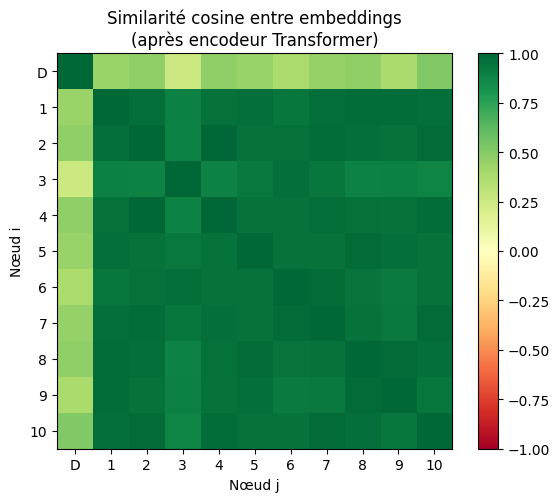

Les nœuds similaires (mêmes TW, même zone) ont des embeddings proches.


In [2]:
node_features_np = compute_static_node_features(instance)  # (N+1, 7)
node_features    = torch.tensor(node_features_np, dtype=torch.float32).unsqueeze(0)  # (1, N+1, 7)

print(f"Entrée encodeur  : {node_features.shape}  [batch, nœuds, features]")

with torch.no_grad():
    h = model.encode(node_features)   # (1, N+1, 128)

print(f"Sortie encodeur  : {h.shape}  [batch, nœuds, d_model]")
print(f"\nEmbedding dépôt  (nœud 0) : min={h[0,0].min():.3f}  max={h[0,0].max():.3f}  norme={h[0,0].norm():.2f}")
print(f"Embedding client 1 (nœud 1) : min={h[0,1].min():.3f}  max={h[0,1].max():.3f}  norme={h[0,1].norm():.2f}")

# Similarité cosine entre nœuds
h0 = h[0]  # (N+1, 128)
norms = h0.norm(dim=1, keepdim=True)
h_norm = h0 / norms
sim = (h_norm @ h_norm.T).numpy()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('Similarité cosine entre embeddings\n(après encodeur Transformer)')
ax.set_xlabel('Nœud j')
ax.set_ylabel('Nœud i')
ax.set_xticks(range(N+1))
ax.set_yticks(range(N+1))
ax.set_xticklabels(['D'] + [str(i) for i in range(1, N+1)])
ax.set_yticklabels(['D'] + [str(i) for i in range(1, N+1)])
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()
print("Les nœuds similaires (mêmes TW, même zone) ont des embeddings proches.")

## 2. Le Décodeur contextuel

À chaque décision, le décodeur calcule un **score** pour chaque nœud candidat, en utilisant l'état courant comme contexte.

### Construction du vecteur requête

```python
h_current = h[current_node]          # embedding du nœud où je suis
h_mean    = h.mean(dim=1)            # résumé global de l'instance
g         = Linear(global_dim→128)(dynamic_global)  # état dynamique projeté

query = Linear(384→128)([h_current | h_mean | g])   # vecteur requête
```

### Calcul des scores

```python
keys   = Linear(128+5→128)([h_i | action_features_i])  # clés enrichies

score_i = (query · key_i) / √128     # produit scalaire normalisé
score_i = 10 · tanh(score_i / 10)    # clipping AM : borne [-10, +10]

logits[infaisable] = -1e9             # masquage des nœuds interdits
```

### Pourquoi `10·tanh` ?
C'est la signature de Kool et al. — sans ce clipping, les scores peuvent exploser et le modèle converge vers des décisions trop déterministes (entropie nulle). Le `tanh` borne les scores dans `[-10, +10]`.

In [3]:
# Prendre le premier exemple du dataset pour illustrer
examples = extract_decision_examples_from_solution(instance, sol)
ex = examples[0]

# Préparer les tenseurs
nf  = torch.tensor(ex['node_features'],   dtype=torch.float32)
af  = torch.tensor(ex['action_features'], dtype=torch.float32)
cn  = torch.tensor(ex['current_node'],    dtype=torch.long)
dg  = torch.tensor(ex['dynamic_global'],  dtype=torch.float32)
fm  = torch.tensor(ex['feasible_mask'],   dtype=torch.float32)

with torch.no_grad():
    logits = model(nf, af, cn, dg, fm)   # (N+1,)

probs = torch.softmax(logits, dim=0).numpy()

print(f"Décision depuis nœud {ex['current_node']} (dépôt)")
print(f"Label oracle : client {ex['target_next_node']}")
print(f"Choix modèle : client {probs.argmax()}")
print()
print(f"{'Nœud':>6} | {'Logit':>8} | {'Proba':>8} | {'Faisable':>9} | Oracle")
print("-" * 50)
for i in range(N + 1):
    label    = 'Dépôt' if i == 0 else f'C{i}'
    faisable = '✓' if fm[i] == 1 else '✗'
    oracle   = '◄ ORACLE' if i == ex['target_next_node'] else ''
    best     = ' ◄ MODÈLE' if i == probs.argmax() and i != ex['target_next_node'] else ''
    print(f"{label:>6} | {logits[i].item():>8.3f} | {probs[i]:>8.4f} | {faisable:>9} | {oracle}{best}")

Décision depuis nœud 0 (dépôt)
Label oracle : client 7
Choix modèle : client 7

  Nœud |    Logit |    Proba |  Faisable | Oracle
--------------------------------------------------
 Dépôt | -1000000000.000 |   0.0000 |         ✗ | 
    C1 |    3.667 |   0.3175 |         ✓ | 
    C2 |   -0.592 |   0.0045 |         ✓ | 
    C3 |    2.914 |   0.1495 |         ✓ | 
    C4 |   -1.478 |   0.0018 |         ✓ | 
    C5 |    0.879 |   0.0195 |         ✓ | 
    C6 |    2.077 |   0.0647 |         ✓ | 
    C7 |    3.713 |   0.3323 |         ✓ | ◄ ORACLE
    C8 |    1.601 |   0.0402 |         ✓ | 
    C9 |    0.827 |   0.0185 |         ✓ | 
   C10 |    1.845 |   0.0513 |         ✓ | 


## 3. Visualisation des scores d'attention

On peut visualiser **ce que le modèle préfère** à chaque étape : les nœuds avec les logits les plus élevés sont ceux que le modèle considère comme les meilleurs prochains à visiter.

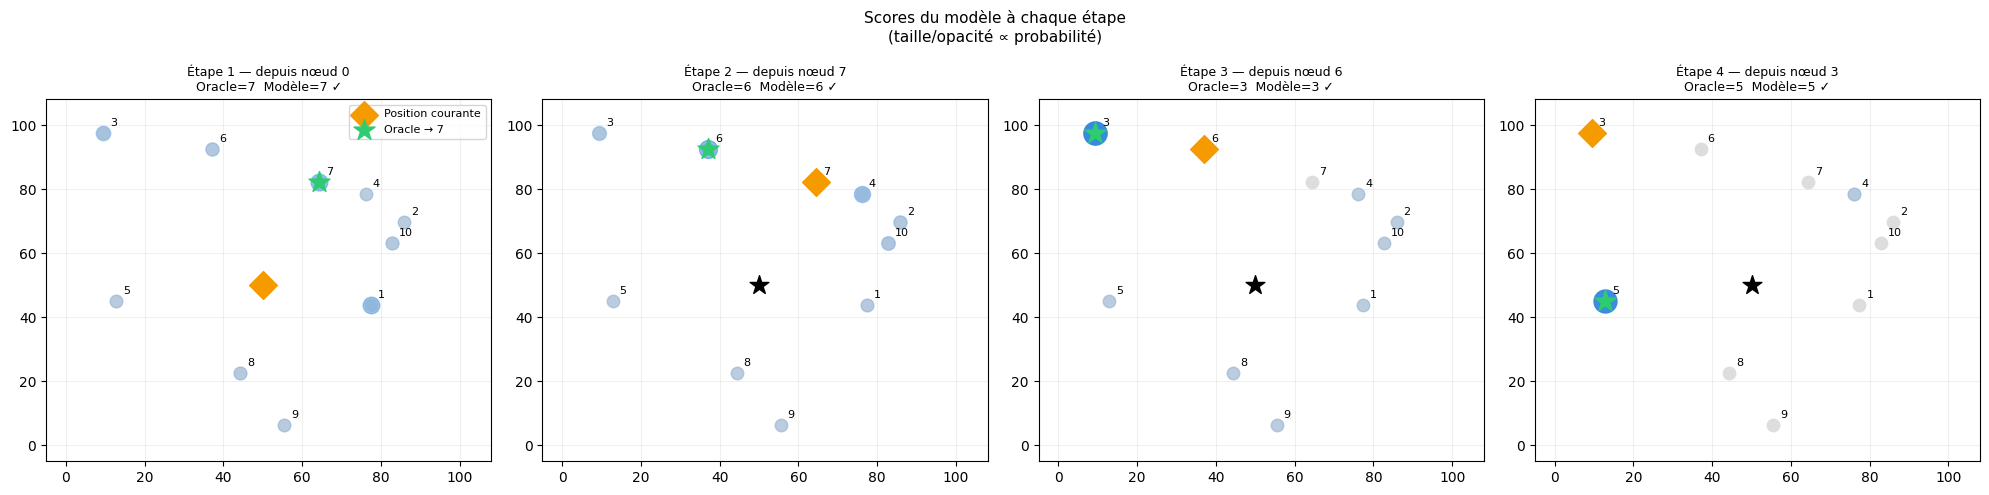

In [4]:
coords = instance['coords']

# Calculer les logits pour toutes les décisions de la première route
fig, axes = plt.subplots(1, min(4, len(examples)), figsize=(5 * min(4, len(examples)), 5))
if len(examples) == 1:
    axes = [axes]

for step, (ex, ax) in enumerate(zip(examples[:4], axes)):
    nf = torch.tensor(ex['node_features'],   dtype=torch.float32)
    af = torch.tensor(ex['action_features'], dtype=torch.float32)
    cn = torch.tensor(ex['current_node'],    dtype=torch.long)
    dg = torch.tensor(ex['dynamic_global'],  dtype=torch.float32)
    fm = torch.tensor(ex['feasible_mask'],   dtype=torch.float32)

    with torch.no_grad():
        logits = model(nf, af, cn, dg, fm).numpy()

    # Normaliser les logits faisables pour la couleur
    feasible_idx = np.where(fm.numpy() > 0)[0]
    logits_feasible = logits[feasible_idx]
    probs = np.exp(logits_feasible - logits_feasible.max())
    probs /= probs.sum()

    # Tous les nœuds en gris
    ax.scatter(coords[1:, 0], coords[1:, 1], c='#DDDDDD', s=80, zorder=2)
    ax.scatter(coords[0, 0],  coords[0, 1],  c='black', s=200, marker='*', zorder=5)

    # Colorier selon la proba du modèle
    for fi, idx in enumerate(feasible_idx):
        if idx == 0:
            continue
        alpha = 0.2 + 0.8 * probs[fi]
        size  = 80 + 200 * probs[fi]
        ax.scatter(coords[idx, 0], coords[idx, 1], c='#378ADD',
                   s=size, alpha=alpha, zorder=3)

    # Nœud courant
    cn_idx = ex['current_node']
    ax.scatter(coords[cn_idx, 0], coords[cn_idx, 1],
               c='#F59B00', s=200, marker='D', zorder=6, label='Position courante')

    # Oracle
    tgt = ex['target_next_node']
    if tgt != 0:
        ax.scatter(coords[tgt, 0], coords[tgt, 1],
                   c='#2ECC71', s=250, marker='*', zorder=7, label=f'Oracle → {tgt}')

    for i in range(1, N+1):
        ax.annotate(str(i), xy=coords[i], xytext=(5,5),
                    textcoords='offset points', fontsize=8)

    modele_choix = feasible_idx[probs.argmax()]
    correct = '✓' if modele_choix == tgt else '✗'
    ax.set_title(f'Étape {step+1} — depuis nœud {cn_idx}\nOracle={tgt}  Modèle={modele_choix} {correct}', fontsize=9)
    ax.set_xlim(-5, 108)
    ax.set_ylim(-5, 108)
    ax.grid(True, alpha=0.2)

axes[0].legend(fontsize=8)
fig.suptitle('Scores du modèle à chaque étape\n(taille/opacité ∝ probabilité)', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Détail de l'architecture — couche par couche

In [5]:
print("=== Architecture VRPTWAttentionModel ===")
print()

total = 0
for name, param in model.named_parameters():
    n_p = param.numel()
    total += n_p
    print(f"  {name:<40} {str(list(param.shape)):<20} {n_p:>8,} params")

print(f"\n  {'TOTAL':<40} {'':20} {total:>8,} params")
print()
print("Hyperparamètres :")
print(f"  node_dim   = 7    (x, y, dem/Q, a/T, b/T, svc/T, depot_flag)")
print(f"  action_dim = 5    (dist, slack, a/T, b/T, dem/Q — dynamiques)")
print(f"  global_dim = 6    (temps/T, charge/Q, %servis, %route, véh, step)")
print(f"  d_model    = 128  (dimension des embeddings)")
print(f"  n_heads    = 8    (têtes d'attention)")
print(f"  n_layers   = 3    (couches Transformer)")

=== Architecture VRPTWAttentionModel ===

  input_proj.weight                        [128, 7]                  896 params
  input_proj.bias                          [128]                     128 params
  encoder.layers.0.self_attn.in_proj_weight [384, 128]             49,152 params
  encoder.layers.0.self_attn.in_proj_bias  [384]                     384 params
  encoder.layers.0.self_attn.out_proj.weight [128, 128]             16,384 params
  encoder.layers.0.self_attn.out_proj.bias [128]                     128 params
  encoder.layers.0.linear1.weight          [512, 128]             65,536 params
  encoder.layers.0.linear1.bias            [512]                     512 params
  encoder.layers.0.linear2.weight          [128, 512]             65,536 params
  encoder.layers.0.linear2.bias            [128]                     128 params
  encoder.layers.0.norm1.weight            [128]                     128 params
  encoder.layers.0.norm1.bias              [128]                     128 pa

## 5. Le forward pass complet — étape par étape

Voici ce qui se passe exactement quand on appelle `model(nf, af, cn, dg, fm)` :

In [6]:
ex = examples[0]
nf = torch.tensor(ex['node_features'],   dtype=torch.float32).unsqueeze(0)  # (1, N+1, 7)
af = torch.tensor(ex['action_features'], dtype=torch.float32).unsqueeze(0)  # (1, N+1, 5)
cn = torch.tensor([ex['current_node']],  dtype=torch.long)                  # (1,)
dg = torch.tensor(ex['dynamic_global'],  dtype=torch.float32).unsqueeze(0)  # (1, 6)
fm = torch.tensor(ex['feasible_mask'],   dtype=torch.float32).unsqueeze(0)  # (1, N+1)

with torch.no_grad():
    # Étape 1 : encodeur
    x  = model.input_proj(nf)        # (1, N+1, 128)  ← projection linéaire
    h  = model.encoder(x)            # (1, N+1, 128)  ← 3× self-attention

    # Étape 2 : contexte du décodeur
    h_current = h[0, cn[0]]          # (128,)  ← embedding du nœud courant
    h_mean    = h.mean(dim=1)        # (1, 128) ← résumé global
    g         = model.global_proj(dg)# (1, 128) ← état dynamique projeté

    ctx   = torch.cat([h_current.unsqueeze(0), h_mean, g], dim=-1)  # (1, 384)
    query = model.context_proj(ctx)                                   # (1, 128)

    # Étape 3 : clés enrichies
    keys  = model.key_proj(torch.cat([h, af], dim=-1))               # (1, N+1, 128)

    # Étape 4 : scores d'attention
    q      = model.W_q(query).unsqueeze(1)                           # (1, 1, 128)
    k      = model.W_k(keys)                                          # (1, N+1, 128)
    scores = (q @ k.transpose(-1,-2)).squeeze() / (128 ** 0.5)       # (N+1,)
    clipped = 10.0 * torch.tanh(scores / 10.0)                       # clipping AM

    # Étape 5 : masquage
    logits = clipped.masked_fill(fm.squeeze() <= 0, -1e9)            # (N+1,)

print("Forward pass détaillé :")
print(f"  1. input_proj   : (1,{N+1},7) → (1,{N+1},128)")
print(f"  2. encoder      : (1,{N+1},128) → (1,{N+1},128)  [3× self-attention]")
print(f"  3. context_proj : h_cur+h_moy+g → query (1,128)")
print(f"  4. key_proj     : [h|af] → keys (1,{N+1},128)")
print(f"  5. scores       : q·kᵀ/√128 → clipé par 10·tanh")
print(f"  6. masquage     : {int((fm==0).sum())} nœuds → -∞")
print()
print(f"Scores avant clipping : min={scores.min():.2f}  max={scores.max():.2f}")
print(f"Scores après clipping : min={clipped.min():.2f}  max={clipped.max():.2f}  (borné [-10, 10])")
print(f"Logits finaux         : {logits.numpy().round(2)}")

Forward pass détaillé :
  1. input_proj   : (1,11,7) → (1,11,128)
  2. encoder      : (1,11,128) → (1,11,128)  [3× self-attention]
  3. context_proj : h_cur+h_moy+g → query (1,128)
  4. key_proj     : [h|af] → keys (1,11,128)
  5. scores       : q·kᵀ/√128 → clipé par 10·tanh
  6. masquage     : 1 nœuds → -∞

Scores avant clipping : min=-1.49  max=3.90
Scores après clipping : min=-1.48  max=3.71  (borné [-10, 10])
Logits finaux         : [-1.00e+09  3.67e+00 -5.90e-01  2.91e+00 -1.48e+00  8.80e-01  2.08e+00
  3.71e+00  1.60e+00  8.30e-01  1.85e+00]


## 6. Pourquoi le Self-Attention est clé

Un MLP simple traite chaque nœud **indépendamment** — il ne voit pas les autres. Le Transformer, lui, calcule des **relations entre tous les nœuds** :

```
MLP :        f(client_3)  →  embedding_3
Transformer: f(client_3, client_1, client_7, dépôt, ...)  →  embedding_3
```

Concrètement : l'embedding du client 3 sait que le client 1 est "proche" et que le client 7 a une fenêtre temporelle urgente — ce qui va influencer la décision de routing.

In [7]:
# Illustrer : l'embedding du client 1 change selon le contexte
# On compare l'embedding de C1 dans notre instance vs une instance modifiée

instance_mod = generate_instance(n=N, seed=SEED + 1)  # instance différente
nf_mod = torch.tensor(
    compute_static_node_features(instance_mod), dtype=torch.float32
).unsqueeze(0)

with torch.no_grad():
    h_orig = model.encode(nf)     # embeddings instance originale
    h_mod  = model.encode(nf_mod) # embeddings instance modifiée

# Comparer les features d'entrée vs la sortie de l'encodeur
print("Effet du Self-Attention : les embeddings dépendent du contexte global")
print()
print(f"Client 1 — features brutes (instance orig) : {nf[0,1,:4].numpy().round(3)}...")
print(f"Client 1 — features brutes (instance mod)  : {nf_mod[0,1,:4].numpy().round(3)}...")
print()
print(f"Client 1 — embedding encodeur (orig) : norme={h_orig[0,1].norm():.2f}  mean={h_orig[0,1].mean():.4f}")
print(f"Client 1 — embedding encodeur (mod)  : norme={h_mod[0,1].norm():.2f}  mean={h_mod[0,1].mean():.4f}")

diff = (h_orig[0,1] - h_mod[0,1]).abs().mean().item()
print(f"\nDifférence absolue moyenne : {diff:.4f}")
print("→ Même client (seed différent) = embedding différent selon les voisins")

Effet du Self-Attention : les embeddings dépendent du contexte global

Client 1 — features brutes (instance orig) : [0.774 0.439 0.06  0.335]...
Client 1 — features brutes (instance mod)  : [0.652 0.044 0.133 0.491]...

Client 1 — embedding encodeur (orig) : norme=6.45  mean=-0.0149
Client 1 — embedding encodeur (mod)  : norme=6.78  mean=-0.0368

Différence absolue moyenne : 0.1523
→ Même client (seed différent) = embedding différent selon les voisins


## Récapitulatif

```
node_features (N, 7)  ──►  Encodeur Transformer (1×/instance)
                                      │
                              h : embeddings (N, 128)
                              "chaque nœud connaît ses voisins"
                                      │
                           ◄──────────┤  (réutilisé à chaque décision)
                           │          │
action_features (N, 5) ──► Décodeur contextuel
current_node, dg, fm  ──►  query = [h_cur | h_moy | g]
                           score_i = q · k_i / √128  →  10·tanh
                           mask infaisables → -∞
                                      │
                              logits (N,)  →  argmax  →  décision
```

**695 936 paramètres** — un modèle relativement léger qui, une fois entraîné, prend une décision en **quelques millisecondes** là où OR-Tools met plusieurs secondes.

→ **Section 5 : l'entraînement** — comment on optimise ces 695k paramètres par imitation.

---

## 7. Structures de données — Tenseurs PyTorch en entrée du modèle

Le modèle reçoit **6 tenseurs** à chaque appel, correspondant à une décision du problème :

### Vue d'ensemble

| Tenseur | Shape | dtype | Rôle |
|---------|-------|-------|------|
| `node_features` | `(N+1, 7)` | float32 | Features statiques de chaque nœud — ne changent pas pendant le décodage |
| `action_features` | `(N+1, 5)` | float32 | Features dynamiques — recalculées à chaque décision selon la position courante |
| `dynamic_global` | `(6,)` | float32 | État global de la tournée (temps, charge, avancement...) |
| `feasible_mask` | `(N+1,)` | float32 | 1 = nœud candidat, 0 = interdit (déjà visité / TW fermée / capacité dépassée) |
| `current_node` | `()` (scalaire) | int64 | Index du nœud où se trouve le véhicule |
| `target_next_node` | `()` (scalaire) | int64 | Décision de l'oracle — label pour l'apprentissage |

---

### Détail : `node_features` — shape (N+1, 7)

Une ligne par nœud (N clients + 1 dépôt). 7 colonnes, toutes **normalisées** entre 0 et 1 :

```
col 0 : x / 100                  — coordonnée X normalisée
col 1 : y / 100                  — coordonnée Y normalisée
col 2 : demande / capacité        — fraction de capacité consommée
col 3 : début fenêtre TW / T_max  — ouverture normalisée
col 4 : fin fenêtre TW / T_max    — fermeture normalisée
col 5 : durée service / T_max     — temps de service normalisé
col 6 : 1 si dépôt, 0 sinon       — flag binaire
```

**Statiques** : calculées une fois par `compute_static_node_features()` avant le décodage.

---

### Détail : `action_features` — shape (N+1, 5)

Dépendent de la **position courante** du véhicule — recalculées à chaque décision par `advance_state_with_target()` :

```
col 0 : distance / D_max     — distance depuis le nœud courant vers ce nœud
col 1 : slack TW / T_max     — marge temporelle (fin_TW - temps_arrivée) / T_max
col 2 : début TW / T_max     — redondant avec node_features mais dans le contexte courant
col 3 : fin TW / T_max       — idem
col 4 : demande / capacité   — fraction de capacité consommée
```

**Dynamiques** : expriment "combien il me coûterait de visiter ce nœud maintenant" — information que l'encodeur statique ne peut pas capturer.

---

### Détail : `dynamic_global` — shape (6,)

Résumé de l'état courant de la tournée, passé au décodeur comme contexte global :

```
pos 0 : temps_courant / T_max          — avancement temporel
pos 1 : charge_courante / capacité      — occupation du véhicule
pos 2 : nb_clients_servis / N           — fraction des clients livrés
pos 3 : nb_clients_dans_route_courante / N  — taille de la route en cours
pos 4 : nb_véhicules_utilisés / N       — nombre de routes ouvertes / N
pos 5 : étape_globale / (N * 2)        — position dans le décodage
```

---

### Détail : `feasible_mask` — shape (N+1,)

Masque binaire indiquant quels nœuds peuvent être visités **légalement** à ce moment :

- `0` → nœud **interdit** : déjà servi, capacité insuffisante, ou fenêtre temporelle fermée
- `1` → nœud **candidat** : peut être le prochain sans violer les contraintes VRPTW

Le dépôt (index 0) est généralement masqué sauf si la route doit se terminer.

---

### La dimension batch `B`

En inférence sur un seul exemple : chaque tenseur a sa shape "naturelle" (N+1, 7), (6,), etc.

En entraînement par `DataLoader` avec `batch_size=64` : `collate_decisions()` empile les exemples et **ajoute une dimension batch** en tête :

```python
node_features   : (N+1, 7)    →  (64, N+1, 7)
action_features : (N+1, 5)    →  (64, N+1, 5)
dynamic_global  : (6,)        →  (64, 6)
feasible_mask   : (N+1,)      →  (64, N+1)
current_node    : ()          →  (64,)
target_next_node: ()          →  (64,)
```

Toutes les couches PyTorch (`nn.Linear`, `nn.TransformerEncoder`, ...) gèrent cette dimension batch **automatiquement**.

In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# STRUCTURES DE DONNÉES — formes, types et valeurs réelles
# ──────────────────────────────────────────────────────────────────────────────
import torch
import numpy as np

ex = examples[0]   # premier exemple de décision (depuis la cellule s04-decoder-code)

print("=" * 65)
print(f"{'Tenseur':<20} {'Shape':<16} {'dtype':<12} {'min':>6}  {'max':>6}")
print("=" * 65)

tensors = {
    'node_features':    (ex['node_features'],   'float32'),
    'action_features':  (ex['action_features'], 'float32'),
    'dynamic_global':   (ex['dynamic_global'],  'float32'),
    'feasible_mask':    (ex['feasible_mask'],    'float32'),
    'target_next_node': ([ex['target_next_node']], 'int64'),
    'current_node':     ([ex['current_node']],  'int64'),
}

for name, (data, dtype) in tensors.items():
    arr = np.array(data)
    print(f"  {name:<18} {str(arr.shape):<16} {dtype:<12} {arr.min():>6.3f}  {arr.max():>6.3f}")

print()
print("Contenu détaillé de chaque tenseur :")
print()

# node_features
nf = np.array(ex['node_features'])  # (N+1, 7)
print(f"node_features ({nf.shape}) — features STATIQUES, une ligne par nœud :")
print(f"  Colonnes : [x/100, y/100, demande/cap, début_TW/T, fin_TW/T, durée_svc/T, is_depot]")
print(f"  Dépôt    (ligne 0) : {nf[0].round(3)}")
print(f"  Client 1 (ligne 1) : {nf[1].round(3)}")
print(f"  Client 2 (ligne 2) : {nf[2].round(3)}")
print()

# action_features
af = np.array(ex['action_features'])  # (N+1, 5)
print(f"action_features ({af.shape}) — features DYNAMIQUES, recalculées à chaque décision :")
print(f"  Colonnes : [dist_depuis_pos_courante, slack_TW, a/T, b/T, demande/cap]")
print(f"  Dépôt    (ligne 0) : {af[0].round(3)}")
print(f"  Client 1 (ligne 1) : {af[1].round(3)}")
print()

# dynamic_global
dg = np.array(ex['dynamic_global'])  # (6,)
print(f"dynamic_global ({dg.shape}) — état global de la tournée courante :")
print(f"  [temps_courant/T, charge_courante/cap, %clients_servis, %route_courante, n_véhicules, étape]")
print(f"  Valeurs : {dg.round(3)}")
print()

# feasible_mask
fm = np.array(ex['feasible_mask'])  # (N+1,)
feasible_idx = np.where(fm > 0)[0]
infeasible_idx = np.where(fm == 0)[0]
print(f"feasible_mask ({fm.shape}) — 1 = nœud candidat, 0 = interdit :")
print(f"  Valeurs       : {fm.astype(int)}")
print(f"  Faisables     : nœuds {list(feasible_idx)}")
print(f"  Infaisables   : nœuds {list(infeasible_idx)}")
print()

# targets
print(f"current_node       : {ex['current_node']}  ← nœud où se trouve le véhicule")
print(f"target_next_node   : {ex['target_next_node']}  ← nœud que l'oracle choisit (label d'apprentissage)")

print()
print("─" * 65)
print("Conversion vers tenseurs PyTorch (dans collate_decisions) :")
print("─" * 65)
nf_t  = torch.tensor(nf, dtype=torch.float32)
af_t  = torch.tensor(af, dtype=torch.float32)
dg_t  = torch.tensor(dg, dtype=torch.float32)
fm_t  = torch.tensor(fm, dtype=torch.float32)
cn_t  = torch.tensor(ex['current_node'], dtype=torch.long)
tgt_t = torch.tensor(ex['target_next_node'], dtype=torch.long)

for name, t in [('node_features', nf_t), ('action_features', af_t),
                ('dynamic_global', dg_t), ('feasible_mask', fm_t),
                ('current_node', cn_t), ('target_next_node', tgt_t)]:
    print(f"  {name:<20} {str(list(t.shape)):<14} {str(t.dtype)}")

Tenseur              Shape            dtype           min     max
  node_features      (11, 7)          float32       0.000   1.000
  action_features    (11, 5)          float32       0.000   1.000
  dynamic_global     (6,)             float32       0.000   0.333
  feasible_mask      (11,)            float32       0.000   1.000
  target_next_node   (1,)             int64         7.000   7.000
  current_node       (1,)             int64         0.000   0.000

Contenu détaillé de chaque tenseur :

node_features ((11, 7)) — features STATIQUES, une ligne par nœud :
  Colonnes : [x/100, y/100, demande/cap, début_TW/T, fin_TW/T, durée_svc/T, is_depot]
  Dépôt    (ligne 0) : [0.5 0.5 0.  0.  1.  0.  1. ]
  Client 1 (ligne 1) : [0.774 0.439 0.06  0.335 0.511 0.014 0.   ]
  Client 2 (ligne 2) : [0.859 0.697 0.274 0.587 0.73  0.02  0.   ]

action_features ((11, 5)) — features DYNAMIQUES, recalculées à chaque décision :
  Colonnes : [dist_depuis_pos_courante, slack_TW, a/T, b/T, demande/cap]
  Dé

## 8. `nn.Module` — La classe de base de tout modèle PyTorch

`VRPTWAttentionModel` hérite de `nn.Module`. Voici ce que ça signifie concrètement :

### Ce que `nn.Module` fournit automatiquement

```python
class VRPTWAttentionModel(nn.Module):
    def __init__(self, ...):
        super().__init__()          # ← OBLIGATOIRE — initialise le registre interne
        self.input_proj = nn.Linear(7, 128)    # ← enregistré comme sous-module
        self.encoder    = nn.TransformerEncoder(...)
        # ...

    def forward(self, nf, af, cn, dg, fm):
        # ← appelé par model(nf, af, cn, dg, fm)
        ...
        return logits
```

| Méthode/attribut | Ce qu'elle fait |
|------------------|-----------------|
| `model.parameters()` | Itère sur tous les tenseurs de poids appris (W, b de chaque couche) |
| `model.named_parameters()` | Même chose, avec le nom de chaque paramètre |
| `model.eval()` | Mode évaluation — désactive Dropout, BatchNorm en mode inférence |
| `model.train()` | Mode entraînement — réactive Dropout, BatchNorm |
| `model.to(device)` | Déplace tous les paramètres vers GPU/CPU |
| `model.state_dict()` | Retourne un dict `{nom: tenseur}` — utilisé pour sauvegarder |
| `model.load_state_dict(d)` | Charge des poids sauvegardés |

### Comment `model(...)` appelle `forward()`

```python
logits = model(nf, af, cn, dg, fm)
#              ↑ Python appelle model.__call__() qui appelle model.forward()
#                model.__call__ fait aussi : enregistrer les hooks, gérer eval/train mode
```

On n'appelle **jamais** `model.forward()` directement — toujours `model(...)`.

### `model.eval()` vs `torch.no_grad()` — différence importante

| | `model.eval()` | `torch.no_grad()` |
|--|--|--|
| Désactive Dropout | ✓ | ✗ |
| Désactive BatchNorm update | ✓ | ✗ |
| Désactive calcul des gradients | ✗ | ✓ |
| Économise la mémoire | ✗ | ✓ |

→ **En inférence, on utilise les deux** : `model.eval()` + `with torch.no_grad()`.

## 9. `nn.Linear` — La brique fondamentale

`nn.Linear(in, out)` applique une **transformation affine** :

```
y = x · Wᵀ + b
```

| Symbole | Shape      | Rôle                        |
|---------|------------|-----------------------------|
| `x`     | `(..., in)`  | entrée (batch possible)    |
| `W`     | `(out, in)`  | matrice de poids **apprise** |
| `b`     | `(out,)`     | biais **appris**           |
| `y`     | `(..., out)` | sortie                     |

**Exemples dans notre modèle** :

```python
input_proj  = nn.Linear(7, 128)     # (N+1, 7) → (N+1, 128)   → 7×128 + 128 = 1024 params
global_proj = nn.Linear(6, 128)     # (1, 6) → (1, 128)        → 6×128 + 128 = 896 params
context_proj= nn.Linear(384, 128)   # (1, 384) → (1, 128)      → 384×128 + 128 = 49 280 params
key_proj    = nn.Linear(133, 128)   # (N+1, 133) → (N+1, 128)  → 133×128 + 128 = 17 152 params
```

**Pourquoi 133 pour key_proj ?** `h` a 128 dims + `af` a 5 dims → concaténés = 133 dims en entrée.

**Pourquoi 384 pour context_proj ?** `h_current`(128) + `h_mean`(128) + `g`(128) = 384 dims.

### Comment PyTorch gère le batch automatiquement

`nn.Linear` fonctionne sur n'importe quelle forme `(..., in)` :
```python
x = torch.randn(64, 11, 7)       # batch_size=64, n_nodes=11, features=7
y = nn.Linear(7, 128)(x)         # → (64, 11, 128)  ← batch géré automatiquement
```

La matmul se fait sur les **deux dernières dimensions**, le reste est traité comme du batch.

## 10. `nn.TransformerEncoderLayer` — Self-Attention et Feed-Forward

Une couche Transformer (il y en a 3 dans notre encodeur) est composée de deux sous-blocs :

### Sous-bloc 1 : Multi-Head Self-Attention (MHSA)

**Intuition** : chaque nœud "interroge" les autres nœuds pour enrichir sa propre représentation.

**Mécanique** (pour une seule tête) :
```
Pour chaque nœud i :
  Q_i = W_Q · h_i    (vecteur requête — "ce que je cherche")
  K_j = W_K · h_j    (vecteur clé    — "ce que j'offre")
  V_j = W_V · h_j    (vecteur valeur — "ce que j'apporte")

  score(i, j) = (Q_i · K_j) / √d_k        # produit scalaire normalisé
  α(i, j)     = softmax(score(i, j))       # poids d'attention
  output_i    = Σ_j α(i,j) · V_j          # combinaison pondérée des valeurs
```

**Multi-tête** : on fait ça 8 fois en parallèle avec des W_Q, W_K, W_V différents, puis on concatène :
```
MHSA = Concat(head_1, ..., head_8) · W_O
```

Chaque tête peut apprendre un **aspect différent** : une tête regarde la proximité géographique, une autre les fenêtres temporelles compatibles, etc.

**Pourquoi diviser par `√d_k` ?** Si d_k = 128/8 = 16, les produits scalaires peuvent être grands. Diviser par √16 = 4 évite que le softmax sature (gradient nul).

---

### Sous-bloc 2 : Feed-Forward Network (FFN)

```python
FFN(x) = Linear(512→128)(ReLU(Linear(128→512)(x)))
#              ↑ réduction                 ↑ expansion × 4
```

La FFN traite chaque nœud **indépendamment** (pas d'interaction entre nœuds) mais dans un espace de dimension 4× plus large. C'est là que la "mémoire" du réseau est stockée.

---

### LayerNorm (pre-norm) — `norm_first=True`

```python
output = x + MHSA(LayerNorm(x))    # pre-norm : normalise AVANT l'attention
output = x + FFN(LayerNorm(x))     # pre-norm : normalise AVANT le FFN
```

La **pré-normalisation** (norm_first=True) stabilise l'entraînement — les gradients ne peuvent pas exploser entre les couches.

**LayerNorm** normalise les activations sur la dimension de feature (pas le batch) :
```
LayerNorm(x_i) = (x_i - μ_i) / σ_i  × γ + β     # γ, β appris
```

---

### Dans notre modèle : 3 couches × 2 sous-blocs

```
Entrée  (N+1, 128)
  ↓ Layer 1 : MHSA → FFN
  ↓ Layer 2 : MHSA → FFN
  ↓ Layer 3 : MHSA → FFN
Sortie  (N+1, 128)   ← chaque nœud "connaît" maintenant tous ses voisins
```

**Paramètres par couche** :
- MHSA : W_Q, W_K, W_V (128×128 chacun) + W_O (128×128) = 4 × 128² = 65 536 params
- Projection in_proj fusionnée Q+K+V : 384×128 = 49 152 params
- FFN : 128×512 + 512×128 = 131 072 params
- LayerNorm ×2 : 128×2 × 2 = 512 params
- **Total par couche ≈ 197 760 params × 3 couches = 593 280 params**

## 11. Opérations PyTorch clés — référence complète

### `torch.no_grad()`

Pendant l'**inférence** (prédiction), on n'a pas besoin de calculer les gradients. PyTorch stocke normalement tout le graphe de calcul pour `.backward()` — ce qui consomme de la mémoire et du temps CPU inutilement.

```python
with torch.no_grad():
    logits = model(nf, af, cn, dg, fm)   # pas de graphe de calcul stocké
```

- Économise ~30-50 % de mémoire GPU
- Accélère le forward pass d'environ 20 %
- **Obligatoire** dans tout code d'inférence (`model.eval()` seul ne suffit pas)

---

### `torch.softmax(logits, dim=0)`

Convertit des **logits** (scores bruts, n'importe quelle valeur réelle) en **probabilités** (entre 0 et 1, somme = 1).

```
softmax(x_i) = exp(x_i) / Σ exp(x_j)
```

| Logit | Probabilité |
|-------|-------------|
| 3.71  | 33.2 %      |
| -0.59 |  0.5 %      |
| 2.91  | 14.9 %      |
| ...   | ...         |

Le modèle ne fait pas lui-même le softmax — la `CrossEntropyLoss` l'applique en interne pendant l'entraînement. En inférence, on l'applique manuellement pour lire les probabilités.

---

### `tensor.masked_fill(mask, value)`

Remplace les positions où `mask == True` par `value`. Utilisé pour neutraliser les nœuds infaisables avant le softmax :

```python
logits.masked_fill(feasible_mask <= 0, -1e9)
#                                       ↑ -∞ → exp(-∞) = 0 → proba = 0
```

**Crucial pour le VRPTW** : sans masquage, le modèle pourrait choisir un client déjà visité ou une livraison impossible.

---

### `torch.tanh()` et le clipping `10·tanh(s/10)`

`tanh` mappe n'importe quel réel vers `(-1, 1)`. En multipliant par 10, on obtient `(-10, 10)`.

```python
score = 10.0 * torch.tanh(score / 10.0)
```

**Pourquoi ?** (Kool et al. 2019)
- Sans clipping : les scores peuvent atteindre ±100 → softmax s'écrase sur un seul nœud → gradient nul → apprentissage bloqué
- Avec clipping : la distribution reste douce, le gradient circule, le modèle apprend mieux

---

### `unsqueeze(dim)` / `squeeze(dim)`

**`unsqueeze(0)`** : ajoute une dimension en position 0 — permet de traiter un exemple unique comme un batch de taille 1.

```python
nf = torch.tensor(...)       # shape : (11, 7)     ← un exemple
nf = nf.unsqueeze(0)         # shape : (1, 11, 7)  ← batch de taille 1
```

**`squeeze(0)`** : l'inverse — supprime une dimension de taille 1.

```python
scores = scores.squeeze()    # (1, 1, 11) → (11,)  ← vecteur de scores
```

Règle d'or : **presque toutes les couches PyTorch attendent une dimension batch** en première position.

---

### Matmul `@` — multiplication matricielle par lot

```python
q   : (B, 1,  d)   # requête  — B=batch, d=dimension
k   : (B, N,  d)   # clés     — N=nombre de nœuds
k.T : (B, d,  N)   # transposée sur les deux dernières dims

q @ k.T : (B, 1, N)  # un score par nœud et par exemple du batch
```

La règle : PyTorch fait la matmul sur les **deux dernières dimensions** et broadcast les dimensions du batch. C'est identique à faire `k` produits scalaires en parallèle.

---

### `.to(device)`

Déplace un tenseur (ou un module) vers un hardware cible :

```python
device = torch.device('cuda')   # GPU NVIDIA
device = torch.device('cpu')    # CPU

model.to(device)                # tous les paramètres → GPU
tensor.to(device)               # ce tenseur → GPU
```

**Règle absolue** : modèle et tenseurs d'entrée doivent être sur le **même device**. Un tenseur CPU passé à un modèle GPU = erreur immédiate.

---

### Gradient flow — comment `.backward()` apprend

Pendant l'entraînement, PyTorch construit un **graphe de calcul** à chaque forward pass. Quand on appelle `loss.backward()`, les gradients se propagent en sens inverse à travers ce graphe (chaîne des dérivées partielles).

```
node_features → input_proj → encoder → decoder → logits → loss
                    ↑             ↑         ↑         ↑
               ∂loss/∂W      ∂loss/∂W  ∂loss/∂W  ∂loss/∂W   ← calculés automatiquement
```

`optimizer.step()` utilise ces gradients pour mettre à jour les poids :
```
W ← W - lr × ∂loss/∂W
```

C'est pourquoi `torch.no_grad()` accélère l'inférence : sans graphe à construire, pas d'allocation mémoire pour les gradients.

In [9]:
# ──────────────────────────────────────────────────────────────────────────────
# DEMO OPÉRATIONS PYTORCH — tout en un endroit
# ──────────────────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn

print("=" * 60)
print("1. torch.no_grad() — désactiver les gradients")
print("=" * 60)
x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
with torch.no_grad():
    y = x * 2          # y n'a PAS de gradient
print(f"x.requires_grad = {x.requires_grad}")
print(f"y.requires_grad = {y.requires_grad}  ← False à l'intérieur du bloc")

print()
print("=" * 60)
print("2. torch.softmax() — logits → probabilités (somme=1)")
print("=" * 60)
logits = torch.tensor([3.71, -0.59, 2.91, -1.48])   # logits bruts du modèle
probs  = torch.softmax(logits, dim=0)
print(f"logits : {logits.numpy().round(2)}")
print(f"probs  : {probs.detach().numpy().round(4)}")
print(f"somme  : {probs.sum().item():.6f}  ← toujours 1.0")

print()
print("=" * 60)
print("3. masked_fill() — mettre -∞ sur les positions infaisables")
print("=" * 60)
logits2 = torch.tensor([3.71, -0.59, 2.91, -1.48])
mask    = torch.tensor([True, False, True, False])   # True = infaisable
logits_masked = logits2.masked_fill(mask, -1e9)
print(f"avant masque : {logits2.numpy().round(2)}")
print(f"masque       : {mask.numpy()}")
print(f"après masque : {logits_masked.numpy()}")
print(f"softmax      : {torch.softmax(logits_masked, dim=0).detach().numpy().round(4)}")
print("→ Les nœuds masqués ont proba ≈ 0.0000")

print()
print("=" * 60)
print("4. torch.tanh() — et le clipping 10·tanh(s/10)")
print("=" * 60)
scores = torch.tensor([-50.0, -5.0, 0.0, 3.0, 5.0, 50.0])
clipped = 10.0 * torch.tanh(scores / 10.0)
print(f"{'score':>8} | {'10·tanh(s/10)':>14}")
print("-" * 25)
for s, c in zip(scores.tolist(), clipped.tolist()):
    print(f"{s:>8.1f} | {c:>14.4f}")
print("→ Les scores restent dans [-10, +10] quelle que soit l'entrée")

print()
print("=" * 60)
print("5. unsqueeze() / squeeze() — ajouter/retirer une dimension")
print("=" * 60)
t1 = torch.randn(11, 7)         # (N+1, features)
t2 = t1.unsqueeze(0)            # (1, N+1, features)  ← dimension batch
t3 = t2.squeeze(0)              # (N+1, features)      ← retirer le batch
print(f"t1.shape = {list(t1.shape)}   ← un seul exemple")
print(f"t2.shape = {list(t2.shape)}  ← avec dimension batch")
print(f"t3.shape = {list(t3.shape)}   ← retirer le batch")

print()
print("=" * 60)
print("6. matmul @ — multiplication matricielle par batch")
print("=" * 60)
B, d, N = 1, 128, 11
q   = torch.randn(B, 1, d)           # (1, 1, 128) — vecteur requête
k   = torch.randn(B, N, d)           # (1, 11, 128) — N clés
scores_mat = q @ k.transpose(-1, -2) # (1, 1, 11) — un score par nœud
scores_sq  = scores_mat.squeeze()    # (11,)
print(f"q.shape              = {list(q.shape)}")
print(f"k.shape              = {list(k.shape)}")
print(f"k.transpose(-1,-2)   = {list(k.transpose(-1,-2).shape)}")
print(f"q @ k.T              = {list(scores_mat.shape)}")
print(f"après squeeze()      = {list(scores_sq.shape)}   ← un score par nœud")

print()
print("=" * 60)
print("7. .to(device) — déplacer un tenseur vers GPU/CPU")
print("=" * 60)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device disponible : {device}")
t_cpu = torch.randn(3, 3)
t_dev = t_cpu.to(device)
print(f"t_cpu.device = {t_cpu.device}")
print(f"t_dev.device = {t_dev.device}")
print("→ Les tenseurs DOIVENT être sur le même device pour opérer ensemble")

1. torch.no_grad() — désactiver les gradients
x.requires_grad = True
y.requires_grad = False  ← False à l'intérieur du bloc

2. torch.softmax() — logits → probabilités (somme=1)
logits : [ 3.71 -0.59  2.91 -1.48]
probs  : [0.681  0.0092 0.306  0.0038]
somme  : 1.000000  ← toujours 1.0

3. masked_fill() — mettre -∞ sur les positions infaisables
avant masque : [ 3.71 -0.59  2.91 -1.48]
masque       : [ True False  True False]
après masque : [-1.00e+09 -5.90e-01 -1.00e+09 -1.48e+00]
softmax      : [0.     0.7089 0.     0.2911]
→ Les nœuds masqués ont proba ≈ 0.0000

4. torch.tanh() — et le clipping 10·tanh(s/10)
   score |  10·tanh(s/10)
-------------------------
   -50.0 |        -9.9991
    -5.0 |        -4.6212
     0.0 |         0.0000
     3.0 |         2.9131
     5.0 |         4.6212
    50.0 |         9.9991
→ Les scores restent dans [-10, +10] quelle que soit l'entrée

5. unsqueeze() / squeeze() — ajouter/retirer une dimension
t1.shape = [11, 7]   ← un seul exemple
t2.shape = [1,